##### Copyright 2026 Google LLC.

In [ ]:
# @title Licensed under the Apache License, Version 2.0 (the "License");
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

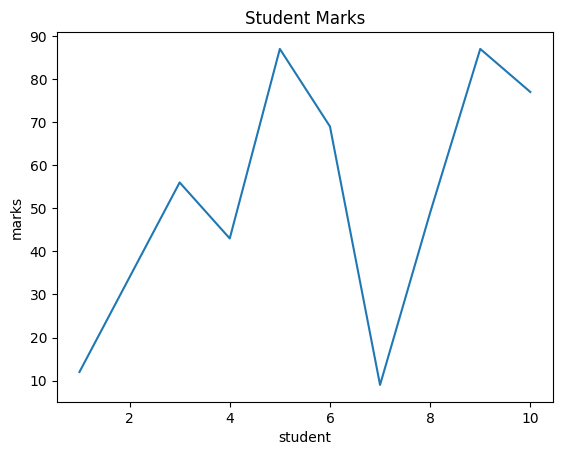

In [35]:
import matplotlib.pyplot as plt
x = [ 1,2,3,4,5,6,7,8,9,10]
y = [12,34,56,43,87,69,9,49,87,77]
plt.plot(x,y)
plt.title("Student Marks")
plt.xlabel("student")
plt.ylabel("marks")
plt.show()

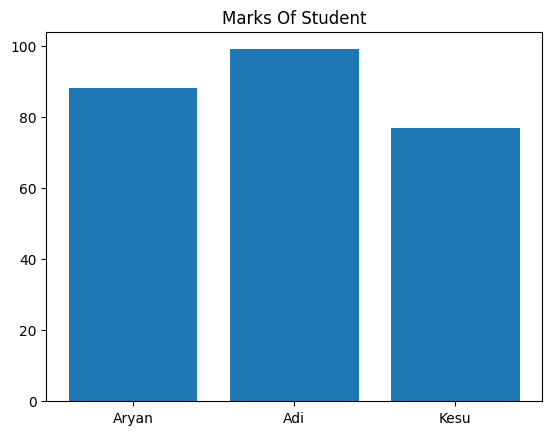

In [37]:
import matplotlib.pyplot as plt
Student = ["Aryan","Adi","Kesu"]
Marks = [88,99,77]
plt.bar(Student,Marks)
plt.title("Marks Of Student")
plt.show()

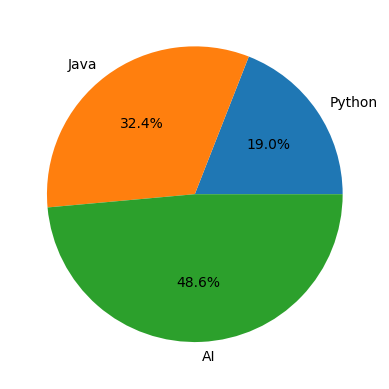

In [38]:
import matplotlib.pyplot as plt
Subject = ["Python","Java","AI"]
Hours = [2,3.4,5.1]
plt.pie(Hours,labels=Subject,autopct="%1.1f%%")
plt.show()

# Gemini Agents API: Build managed agents with the Interactions API

<a class="tfo-notebook-buttons" target="_blank" href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_managed_agents.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" height=30/></a>

The [Interactions API](https://ai.google.dev/gemini-api/docs/interactions) provides a unified interface for working with Gemini models and agents. The [Getting Started notebook](./Get_started_interactions_api.ipynb) covers how to use it with standard Gemini **models** for text generation, multi-turn conversations, and tool use.

This notebook focuses on something different: **managed agents** with the `antigravity-preview-05-2026` agent.

### `agent=` vs `model=`

When you call the Interactions API, you choose between two modes:

| Parameter | What runs | Best for |
|-----------|-----------|----------|
| `model="gemini-..."` | A standard Gemini model | Text generation, structured output, function calling |
| `agent="antigravity-preview-05-2026"` | A **managed agent** in a sandboxed Linux environment | Autonomous tasks: code execution, web research, file management |

With `model=`, you get a stateless LLM call (see the [Getting Started notebook](./Get_started_interactions_api.ipynb)). With `agent=`, you spin up an autonomous agent that can **reason, plan, write and execute code, browse the web, and manage files** — all inside a secure sandbox, without you writing any orchestration logic.

This notebook walks you through the agent mode step by step:

1. **Simple questions** — use the agent like an LLM (it works, but it's overkill!)
2. **Multi-turn conversations** — persistent sandbox = built-in memory
3. **Using tools** — code execution, web search, file operations
4. **Loading data into the sandbox** — inject files before the agent starts
5. **Creating reusable custom agents** — bundle instructions, skills, and environment

<a name="setup"></a>
## Setup

### Install SDK

Install the SDK from [PyPI](https://github.com/googleapis/python-genai). It's recommended to always use the latest version.

In [ ]:
%pip install -U -q "google-genai>=2.9.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 818.2/818.2 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.1/246.1 kB 6.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.47.0, but you have google-auth 2.53.0 which is incompatible.
google-cloud-aiplatform 1.148.1 requires google-genai<2.0.0,>=1.66.0; python_version >= "3.10", but you have google-genai 2.4.0 which is incompatible.
google-adk 1.29.0 requires google-genai<2.0.0,>=1.64.0, but you have google-genai 2.4.0 which is incompatible.


### Setup your API key

To run the following cell, your API key must be stored it in a Colab Secret named `GEMINI_API_KEY`. If you don't already have an API key or you aren't sure how to create a Colab Secret, see [Authentication ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](../quickstarts/Authentication.ipynb) for an example.

In [ ]:
from google.colab import userdata

GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')

### Initialize SDK client

With the new SDK, now you only need to initialize a client with you API key.

In [ ]:
import uuid
from google import genai
from google.genai import types
from IPython.display import Markdown

client = genai.Client(api_key=GEMINI_API_KEY)

# The default managed agent.
AGENT = "antigravity-preview-05-2026"

# Generate a unique suffix for this notebook session to prevent agent ID conflicts
UNIQUE_SUFFIX = uuid.uuid4().hex[:8]

print("Client ready!")

Client ready!


## 1. Simple questions — the agent as an LLM

The simplest way to use a managed agent is to ask it a question, just like you'd call a standard Gemini model. Pass `agent="antigravity-preview-05-2026"` and `environment="remote"` to create a fresh Linux sandbox for the agent.

This works, but it's a bit like driving a Formula 1 car to the grocery store — the agent has code execution, web search, and file management capabilities that are all sitting idle for a simple factual question.

In [ ]:
interaction = client.interactions.create(
    agent=AGENT,
    input="What is the capital of France?",
    environment="remote",
)

Markdown(interaction.output_text)

/tmp/ipykernel_2790/271594579.py:1: UserWarning: Interactions usage is experimental and may change in future versions.
  interaction = client.interactions.create(


The capital of France is Paris.

In [ ]:
# The response also includes metadata about the agent's sandbox.
print(f"Status:         {interaction.status}")
print(f"Interaction ID: {interaction.id}")
print(f"Environment ID: {interaction.environment_id}")

Status:         completed
Interaction ID: v1_Chc1SlFNYXVmUE51YXNqckVQM09laGlBYxIXNUpRTWF1ZlBOdWFzanJFUDNPZWhpQWM
Environment ID: fc155701-ea68-4846-973f-f2943e35cdde


Notice the `environment_id` in the response. That's the agent's persistent Linux sandbox. Even for this simple question, a full container was provisioned. Let's make use of that persistence next.

## 2. Multi-turn conversations

Since each agent runs in a persistent sandbox, you can **continue where you left off** by reusing the `environment_id` and linking turns with `previous_interaction_id`.

This is fundamentally different from stateless `model=` calls. The agent has a true *persistent environment* — files it creates stick around, packages it installs remain available, and conversation context is preserved.

In [ ]:
# Turn 1: Introduce yourself.
turn1 = client.interactions.create(
    agent=AGENT,
    input="Hi! My name is Alice and I'm a software engineer. Remember that in a knowledge.md doc.",
    environment= "remote",
)

Markdown(f"**Turn 1:** {turn1.output_text}")

**Turn 1:** Hi Alice! Nice to meet you. 

I have created a `knowledge.md` file in the working directory and saved your profile details:
* **Name:** Alice
* **Role:** Software Engineer

I'll keep this in mind for our future interactions! Let me know how I can help you with your tasks today.

In [ ]:
# Turn 2: Ask whether the agent remembers.
# Pass environment_id and previous_interaction_id to continue the conversation.
turn2 = client.interactions.create(
    agent=AGENT,
    input="what's my name and what do I do?",
    environment= turn1.environment_id,
)

Markdown(f"**Turn 2:** {turn2.output_text}")

**Turn 2:** Based on the information in `knowledge.md`, here are your details:

* **Name:** Alice
* **What you do:** You are a Software Engineer.

The agent remembered across turns because you passed `environment` with the previous environment ID — same sandbox, which means same files.

You could have achieved the same result using `previous_interaction_id` to keep the history of the previous conversation, but that would not have showcased the environement specificities.

This is how you build stateful, multi-turn workflows. See the [Getting Started notebook](./Get_started_interactions_api.ipynb) for `model=`-based multi-turn using `previous_interaction_id` alone (without environments).

## 3. Using tools — where the agent shines

This is where managed agents go beyond a standard chat model. The antigravity-preview-05-2026 agent has **built-in tools** it uses autonomously — you don't declare them, just describe your goal and the agent figures out what to use.

| Tool | Description |
|------|-------------|
| `bash` | Execute shell commands in the sandbox |
| `google_search` | Search the web for current information |
| `url_context` | Fetch and extract text from URLs |
| `write_file` | Create or overwrite files in the sandbox |
| `read_file` | Read file contents from the sandbox |
| `list_files` | List directory contents |
| `delete_file` | Remove files from the sandbox |

For the standard `model=`-based tools (Google Search grounding, code execution, function calling), see the [Getting Started notebook](./Get_started_interactions_api.ipynb) and the dedicated tool notebooks:
- [Code Execution](./Code_Execution.ipynb)
- [Search Grounding](./Search_Grounding.ipynb)
- [Function Calling](./Function_calling.ipynb)

### Code execution

Ask a computational question and the agent will write code, run it in its sandbox, and return the verified result.

In [ ]:
interaction = client.interactions.create(
    agent=AGENT,
    input=(
        "Write a Python script that computes the first 20 Fibonacci numbers. "
        "Run it and show the output."
    ),
    environment="remote",
)

Markdown(interaction.output_text)

I have created and executed a Python script to compute the first 20 Fibonacci numbers.

### Python Script (`fibonacci.py`)

Here is the code written to `fibonacci.py`:

```python
def fibonacci(n):
    if n <= 0:
        return []
    elif n == 1:
        return [0]
    
    fib_sequence = [0, 1]
    while len(fib_sequence) < n:
        fib_sequence.append(fib_sequence[-1] + fib_sequence[-2])
    return fib_sequence

if __name__ == "__main__":
    n = 20
    fib_numbers = fibonacci(n)
    print(f"The first {n} Fibonacci numbers are:")
    print(fib_numbers)
```

### Execution Output

Running this script yields the following result:

```text
The first 20 Fibonacci numbers are:
[0, 1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377, 610, 987, 1597, 2584, 4181]
```

### Inspecting steps — what the agent actually did

The `steps` field in the response shows the agent's reasoning chain: its thoughts, tool calls, tool results, and final output. This is useful for debugging and understanding the agent's behavior.

In [ ]:
# Inspect the steps from the Fibonacci interaction above.
for i, step in enumerate(interaction.steps):
    step_type = step.type
    print(f"--- Step {i} [{step_type}] ---")

    # Tool call steps show which tool was invoked and with what arguments.
    if hasattr(step, "name") and step.name:
        print(f"  Tool: {step.name}")
        if hasattr(step, "arguments"):
            args_str = str(step.arguments)[:300]
            print(f"  Args: {args_str}")

    # Content steps contain the agent's text output.
    if hasattr(step, "content") and step.content:
        for c in step.content:
            if hasattr(c, "text"):
                print(f"  Text: {c.text[:300]}")
    print()

--- Step 0 [thought] ---

--- Step 1 [function_call] ---
  Tool: write_file
  Args: {'path': '/fibonacci.py', 'content': 'def fibonacci(n):\n    if n <= 0:\n        return []\n    elif n == 1:\n        return [0]\n    \n    fib_sequence = [0, 1]\n    while len(fib_sequence) < n:\n        fib_sequence.append(fib_sequence[-1] + fib_sequence[-2])\n    return fib_sequence\n\nif __name_

--- Step 2 [function_result] ---
  Tool: write_file

--- Step 3 [code_execution_call] ---

--- Step 4 [code_execution_result] ---

--- Step 5 [model_output] ---
  Text: I have created and executed a Python script to compute the first 20 Fibonacci numbers.

### Python Script (`fibonacci.py`)

Here is the code written to `fibonacci.py`:

```python
def fibonacci(n):
    if n <= 0:
        return []
    elif n == 1:
        return [0]
    
    fib_sequence = [0, 1]
   



### Web search

The agent can search the web autonomously when it needs up-to-date information.

In [ ]:
interaction = client.interactions.create(
    agent=AGENT,
    input="What were the top 3 news stories about Google this week? Summarize them briefly.",
    environment="remote",
)

Markdown(interaction.output_text)

The week of May 12–19, 2026, has been exceptionally busy for Google, dominated by the kickoff of **Google I/O 2026** and its preliminary event, **"The Android Show."** 

Here are the top three major news stories about Google from this week:

---

### 1. Google Unveils the "Googlebook" — The Successor to the Chromebook
Google announced a brand-new, high-end laptop class called the **Googlebook**, designed to compete directly with Apple’s MacBooks and Microsoft’s AI-centric Copilot+ PCs [1, 2]. 
* **The Software:** The laptops will run a newly designed hybrid, on-device OS codenamed **"Aluminium OS"** (based on Android and ChromeOS) [2]. 
* **Key Features:** Googlebooks are marketed as "the first laptops built from the ground up for Gemini Intelligence" [2]. They will feature a nostalgic retro-style **rainbow light bar** on the lid, along with unique interaction features like **"Magic Pointer"**—a gesture tool that lets users shake their cursor to prompt context-aware AI suggestions (e.g., automatically scheduling a calendar event from highlighted text) [1].

### 2. Android 17 Showcased Along with Hardware Exclusion Backlash
During *The Android Show*, Google gave a detailed preview of **Android 17**, highlighting deep integration with on-device AI [3, 5]. However, the announcement has triggered a wave of user dissatisfaction regarding device compatibility [4].
* **The Features:** Android 17 introduces **Gemini Intelligence**, which handles multi-step app automation and custom AI widgets [5]. Other features include **"Rambler"** (a multilingual dictation tool capable of polishing spoken text, including natural code-switching like Hinglish) and native **AirDrop compatibility** for Google's Quick Share on supported devices [5].
* **The Controversy:** Google revealed that the marquee Gemini Intelligence features require the advanced hardware specs of **Gemini Nano v3** [4]. This rules out almost all older phones—including the highly popular **Pixel 9 series** launched just a year prior—prompting widespread backlash from premium phone buyers over artificial hardware limitations [4].

### 3. Google DeepMind Launches "AI for the Planet" Climate Accelerator in APAC
Google DeepMind announced its inaugural **Asia-Pacific (APAC) Accelerator** program dedicated to environmental sustainability [6, 7].
* **The Program:** This three-month program is tailored for climate tech startups, non-profits, and research teams operating in the APAC region [7]. 
* **What it Offers:** Kicking off with an in-person bootcamp in Singapore, selected teams will receive intensive, direct mentorship from Google AI researchers, technical assistance, and support in integrating DeepMind's scientific and generative AI models to help scale real-world climate and nature resilience projects [6, 7].

---

### Sources
* [1] [PCMag: Reinventing the Laptop with Googlebook](https://www.pcmag.com/opinions/with-the-googlebook-im-betting-on-google-to-reinvent-the-laptop-again)
* [2] [Axios: Googlebook Built for Gemini](https://www.axios.com/2026/05/12/googlebook-ai-chromebook-announcement)
* [3] [CNET: Android 17 Previewed with Gemini Intelligence](https://www.cnet.com/tech/services-and-software/android-17-preview/)
* [4] [HowToGeek: Steep Requirements for Gemini Intelligence](https://www.howtogeek.com/gemini-intelligence-android-17-device-requirements/)
* [5] [Times of India: Google I/O 2026 Android 17 Updates](https://timesofindia.indiatimes.com/technology/tech-news/google-i/o-2026-android-17-updates-android-xr-gemini-intelligence-and-other-things-to-expect/articleshow/131198172.cms)
* [6] [Google Blog: Launching Google DeepMind APAC Accelerator Program](https://blog.google/innovation-and-ai/models-and-research/google-deepmind/accelerator-ai-for-the-planet/)
* [7] [ESG News: DeepMind APAC Climate Accelerator](https://esgnews.com/google-deepmind-launches-apac-ai-accelerator-to-scale-climate-nature-solutions/)

### File operations

The agent can create, read, and manage files in its sandbox. Files persist within the environment across turns.

In [ ]:
# Ask the agent to create a file, run it, and show results.
interaction = client.interactions.create(
    agent=AGENT,
    input=(
        "Create a Python file called 'analysis.py' that generates 50 random numbers, "
        "computes mean, median, and standard deviation, then prints the results. "
        "Run it and show the output."
    ),
    environment="remote",
)

Markdown(interaction.output_text)

I have created the Python script `analysis.py` and executed it. 

### Python Script (`analysis.py`)
```python
import random
import statistics

# Set seed for reproducibility (optional, but good for consistency)
random.seed(42)

# Generate 50 random numbers between 1 and 100
numbers = [random.uniform(1, 100) for _ in range(50)]

# Calculate statistics
mean_val = statistics.mean(numbers)
median_val = statistics.median(numbers)
stdev_val = statistics.stdev(numbers)

# Print results
print("Generated 50 random numbers:")
print([round(num, 2) for num in numbers])
print(f"\nMean: {mean_val:.4f}")
print(f"Median: {median_val:.4f}")
print(f"Standard Deviation: {stdev_val:.4f}")
```

### Execution Output
```text
Generated 50 random numbers:
[64.3, 3.48, 28.23, 23.1, 73.91, 67.99, 89.33, 9.61, 42.77, 3.95, 22.65, 51.03, 3.63, 20.68, 65.34, 54.95, 22.82, 59.34, 81.13, 1.64, 80.78, 70.12, 34.68, 16.39, 95.76, 34.32, 10.18, 10.57, 84.9, 60.77, 80.91, 73.24, 54.09, 97.34, 38.47, 55.65, 83.11, 62.23, 86.31, 58.16, 70.75, 5.54, 23.56, 29.65, 8.9, 24.05, 11.0, 28.52, 63.93, 37.12]

Mean: 45.6177
Median: 46.9002
Standard Deviation: 29.0356
```

## 4. Loading data into the agent's sandbox

You can inject files into the agent's environment **before it starts** using `sources`. This is how you provide data, configuration, or code for the agent to work with.

| Source type | Description | Best for |
|------------|-------------|----------|
| `inline` | Embed content directly (max 75 KB) | Config files, small scripts |
| `gcs` | Load from Google Cloud Storage | Large datasets |
| `repository` | Load from GitHub | Code repositories |

In [ ]:
# Inject a CSV file inline and ask the agent to analyze it.
csv_data = """name,age,city,score
              Alice,28,Paris,92
              Bob,35,London,87
              Charlie,42,Berlin,95
              Diana,31,Tokyo,88
              Eve,26,Sydney,91"""

interaction = client.interactions.create(
    agent=AGENT,
    input="Read the file data.csv, analyze it, and tell me who scored the highest.",
    environment={
        "type": "remote",
        "sources": [
            {
                "type": "inline",
                "content": csv_data,
                "target": "/workspace/data.csv",
            }
        ],
    },
)

Markdown(interaction.output_text)

Based on the data in `workspace/data.csv`, **Charlie** scored the highest with a score of **95**.

Here is a breakdown of the scores in the file:

| Name | Age | City | Score |
| :--- | :--- | :--- | :--- |
| **Charlie** | **42** | **Berlin** | **95 (Highest)** |
| Alice | 28 | Paris | 92 |
| Eve | 26 | Sydney | 91 |
| Diana | 31 | Tokyo | 88 |
| Bob | 35 | London | 87 |

You can also load from other sources:

```python
# From Google Cloud Storage
{"type": "gcs", "source": "gs://my-bucket/data/", "target": "/workspace/data/"}

# From a GitHub repository
{"type": "repository", "source": "https://github.com/user/repo", "target": "/workspace/repo/"}
```

You can combine multiple sources in a single request — the agent will have access to all of them at startup.

**Pro tip:** You can use that to add skills to you agent, as you'll see next.

## 5. Creating reusable custom agents

So far, every interaction has used the base `antigravity-preview-05-2026` agent with inline instructions. Once you've found a setup that works well, you can **persist it into a named custom agent** that bundles:

- **Instructions** — system prompt that defines the agent's behavior
- **Environment** — pre-configured sandbox with files and sources
- **Skills** — `SKILL.md` files that teach the agent specialized capabilities

This is the recommended workflow:
1. **Prototype** with `agent="antigravity-preview-05-2026"` — iterate on instructions, sources, and prompts
2. **Create** a named agent via the `/agents` endpoint
3. **Invoke** your agent by name from any client

### Creating a custom agent

In [ ]:
# Create a custom data analysis agent using the SDK.
my_agent = client.agents.create(
    id=f"my-data-analyst-{UNIQUE_SUFFIX}",
    base_agent=AGENT,
    system_instruction=(
        "You are a data analysis assistant. "
        "Always write Python code using pandas to answer questions. "
        "Show your code and output clearly. "
        "When creating visualizations, save them as PNG files."
    ),
    base_environment={
        "type": "remote",
    },
)

print(f"✓ Agent created: {my_agent.id}")

✓ Agent created: my-data-analyst


### Using a custom agent

Once created, invoke your agent by name. It will follow its instructions automatically.

In [ ]:
# Invoke the custom agent.
interaction = client.interactions.create(
    agent=f"my-data-analyst-{UNIQUE_SUFFIX}",
    input=(
        "Generate a sample dataset of 100 sales records with columns: "
        "product, region, revenue, quantity. "
        "Find the top 5 products by total revenue and show the analysis."
    ),
    environment="remote",
)

Markdown(interaction.output_text)

I have generated a sample dataset of 100 sales records and performed a data analysis to find the top 5 products by total revenue. 

The sample dataset has been successfully saved to `sales_data.csv` and the corresponding visualization has been saved as `top_products_revenue.png`.

Below is the complete, step-by-step breakdown of the Python code used, the data previews, and the detailed analysis.

---

### Step 1: Generating the Sample Dataset

We used `pandas` and `numpy` to generate a realistic set of 100 sales transactions. To make the data realistic, we mapped individual products to base prices and applied a random variance of $\pm 10\%$ to mimic real-world discounts and transactional pricing.

Here is the Python code to generate and save the dataset:

```python
import pandas as pd
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

# Define products and base unit prices
product_prices = {
    'Laptop': 1000,
    'Smartphone': 700,
    'Tablet': 400,
    'Headphones': 150,
    'Smartwatch': 250,
    'Monitor': 300,
    'Keyboard': 80,
    'Mouse': 50,
    'Printer': 200,
    'Router': 120
}

products = list(product_prices.keys())
regions = ['North', 'East', 'South', 'West']

# Generate 100 sales records
n_records = 100
random_products = np.random.choice(products, size=n_records)
random_regions = np.random.choice(regions, size=n_records)
random_quantities = np.random.randint(1, 15, size=n_records)

# Calculate revenue with small price variations (e.g., matching discounts/promotions)
random_revenues = []
for prod, qty in zip(random_products, random_quantities):
    base_price = product_prices[prod]
    variation = np.random.uniform(0.9, 1.1)
    revenue = round(base_price * qty * variation, 2)
    random_revenues.append(revenue)

# Create DataFrame
df = pd.DataFrame({
    'product': random_products,
    'region': random_regions,
    'revenue': random_revenues,
    'quantity': random_quantities
})

# Save to CSV
df.to_csv('sales_data.csv', index=False)
```

#### Dataset Preview (First 10 Rows of `sales_data.csv`)

| | product | region | revenue | quantity |
|---|---|---|---|---|
| **0** | Keyboard | West | $73.49 | 1 |
| **1** | Headphones | East | $485.75 | 3 |
| **2** | Mouse | North | $540.04 | 10 |
| **3** | Smartwatch | West | $3,079.86 | 12 |
| **4** | Keyboard | South | $619.40 | 8 |
| **5** | Router | South | $1,280.19 | 11 |
| **6** | Tablet | East | $2,508.46 | 6 |
| **7** | Keyboard | West | $690.83 | 8 |
| **8** | Mouse | North | $484.84 | 9 |
| **9** | Smartwatch | South | $1,055.98 | 4 |

---

### Step 2: Analyzing the Top 5 Products by Total Revenue

Using `pandas`, we grouped the dataset by **product**, aggregated the total revenue and quantities, and extracted the top 5 highest-grossing products.

```python
import pandas as pd

# Load the generated dataset
df = pd.read_csv('sales_data.csv')

# Group and aggregate
product_analysis = df.groupby('product').agg(
    total_revenue=('revenue', 'sum'),
    total_quantity=('quantity', 'sum'),
    average_transaction_value=('revenue', 'mean'),
    transaction_count=('product', 'count')
).reset_index()

# Sort by revenue and get top 5
top_5_products = product_analysis.sort_values(by='total_revenue', ascending=False).head(5)

# Format and display
formatted_top_5 = top_5_products.copy()
formatted_top_5['total_revenue'] = formatted_top_5['total_revenue'].map('${:,.2f}'.format)
formatted_top_5['average_transaction_value'] = formatted_top_5['average_transaction_value'].map('${:,.2f}'.format)
print(formatted_top_5.to_string(index=False))
```

#### Analysis Output

| product | total_revenue | total_quantity | average_transaction_value | transaction_count |
| :--- | :--- | :--- | :--- | :--- |
| **Laptop** | \$54,845.99 | 54 | \$7,835.14 | 7 |
| **Smartphone** | \$48,213.02 | 70 | \$4,821.30 | 10 |
| **Tablet** | \$20,754.26 | 49 | \$2,306.03 | 9 |
| **Smartwatch** | \$17,331.45 | 70 | \$1,733.14 | 10 |
| **Printer** | \$14,501.77 | 71 | \$1,208.48 | 12 |

#### Key Insights from the Product Analysis
1. **Laptops** generated the highest total revenue (**\$54,845.99**), despite having a lower transaction count (7) and total quantity sold (54). This is driven by their high unit value, resulting in a high average transaction value of **\$7,835.14**.
2. **Smartphones** are a close second with **\$48,213.02** in total revenue, driven by solid volume (70 units across 10 transactions).
3. **Printers** saw the highest volume of transactions (12) and units sold (71) among the top 5, but because of their lower unit price, they sit in fifth place with **\$14,501.77** in revenue.

---

### Step 3: Visualizing the Results

We used `matplotlib` and `seaborn` to build a publication-quality bar chart representing the top 5 products and saved it as `top_products_revenue.png`.

```python
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Create barplot
barplot = sns.barplot(
    data=top_5_products,
    x='total_revenue',
    y='product',
    palette='viridis',
    hue='product',
    legend=False
)

# Annotate each bar with its revenue value
for p in barplot.patches:
    width = p.get_width()
    plt.text(
        width + 500,  # X offset
        p.get_y() + p.get_height() / 2,
        f'${width:,.2f}',
        ha='left',
        va='center',
        fontsize=10,
        fontweight='bold',
        color='#333333'
    )

plt.title('Top 5 Products by Total Revenue', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Total Revenue (USD)', fontsize=12, labelpad=10)
plt.ylabel('Product', fontsize=12, labelpad=10)
plt.xlim(0, top_5_products['total_revenue'].max() * 1.15) # Add margin for labels

plt.tight_layout()
plt.savefig('top_products_revenue.png', dpi=300)
plt.close()
```

The resulting high-resolution chart (`top_products_revenue.png`) provides a clear visual distinction between the premium earners (Laptops and Smartphones) and the mid-tier products (Tablets, Smartwatches, and Printers).

---

### Step 4: Bonus Analysis — Regional Revenue Performance

To add more value to the analysis, we also grouped the dataset by **region** to see where sales are strongest.

```python
# Group by region
regional_sales = df.groupby('region').agg(
    total_revenue=('revenue', 'sum'),
    total_quantity=('quantity', 'sum'),
    transaction_count=('product', 'count')
).reset_index()

# Format and display
regional_sales['total_revenue'] = regional_sales['total_revenue'].map('${:,.2f}'.format)
print(regional_sales.to_string(index=False))
```

#### Regional Performance Output

| region | total_revenue | total_quantity | transaction_count |
| :--- | :--- | :--- | :--- |
| **South** | \$75,877.06 | 210 | 31 |
| **North** | \$48,667.68 | 190 | 26 |
| **East** | \$40,204.98 | 126 | 21 |
| **West** | \$29,124.71 | 118 | 22 |

* **Regional Takeaway:** The **South** region is by far the strongest performer, contributing **\$75,877.06** in total revenue (over 39% of all sales) and leading in both quantities sold and transaction count.

### Creating an agent with pre-loaded data

You can define the agent's environment with sources, so data is ready before the agent starts:

In [ ]:
# Create an agent with GCS sources pre-loaded using the SDK.
my_slides_agent = client.agents.create(
    id=f"my-gemini-api-agent-{UNIQUE_SUFFIX}",
    base_agent=AGENT,
    system_instruction=(
        "You are a software engineer speciliazed in the Gemini API. "
        "Use the skills available in /.agents/skills/ to create amazing apps."
    ),
    base_environment={
        "type": "remote",
        "sources": [
            {
                "type": "repository",
                "source": "https://github.com/google-gemini/gemini-skills",
                "target": "/.agents/skills",
            }
        ],
    },
)

print(f"✓ Agent created: {my_slides_agent.id}")

✓ Agent created: my-gemini-api-agent


In [ ]:
# Invoke the custom agent.
interaction = client.interactions.create(
    agent=f"my-gemini-api-agent-{UNIQUE_SUFFIX}",
    input="Tell me what you can do with your skills?",
    environment="remote",
)

Markdown(interaction.output_text)

As a software engineer specializing in the **Gemini API**, I have access to three highly specialized skill sets that allow me to design, build, and deploy cutting-edge AI-driven applications. 

Here is what I can do with my specialized skills:

---

### 1. Gemini API Development (`gemini-api-dev`)
This skill covers standard, hosted model integration across multiple programming languages (Python, JavaScript/TypeScript, Go, and Java) using the modern unified `google-genai` SDKs.

*   **Implement Next-Generation Models:** I can build apps using Google's latest models, such as **Gemini 3.5 Flash** (`gemini-3.5-flash`), **Gemini 3.1 Pro** (`gemini-3.1-pro-preview`), and the **Gemma 4** open-model family (`gemma-4-31b-it`). *(Note: Legacy models like `gemini-2.0-*` and `gemini-1.5-*` are deprecated and avoided.)*
*   **Multimodal Applications:** I can build solutions that seamlessly process and analyze diverse inputs including text, high-resolution images, audio, and video files.
*   **Structured Outputs:** I can configure models to return strict, type-safe JSON data matching your precise schemas for reliable application-level parsing.
*   **Function Calling & Tool Use:** I can extend model capabilities by declaring client-side functions that the model can choose to call based on user queries, allowing real-time integrations with external APIs and databases.

---

### 2. Gemini Interactions API (`gemini-interactions-api`)
This skill focuses on stateful, timeline-based conversational flows, background research tasks, and advanced autonomous agent architectures. It adheres to the modern May 2026 schema, which utilizes a structured `steps` timeline.

*   **Stateful Conversations:** I can build chat applications that maintain server-side interaction history, making multi-turn chat simpler and more context-rich without having to manually pass complete histories back and forth.
*   **Deep Research Agent Orchestration:** I can construct autonomous pipelines using agents like `deep-research-preview-04-2026` to run background, multi-step, interactive research tasks with automatic progress-polling patterns.
*   **Remote Managed Agents:** I can spin up and orchestrate **Antigravity Agents** (`antigravity-preview-05-2026`) operating in remote, Google-hosted Linux sandboxes. These agents can autonomously execute Python or Node.js code, run Bash commands, manage remote workspaces, and search the web.
*   **Custom Multi-Agent Systems:** I can program custom remote agents by defining base environments, seeding GitHub repositories directly into the sandboxes, and overriding system instructions to build dedicated code-reviewers, data-analysts, or security auditors.

---

### 3. Gemini Live API Development (`gemini-live-api-dev`)
This skill allows me to build low-latency, real-time, bidirectional voice and video streaming experiences over WebSockets.

*   **Low-Latency Audio Conversations:** Using `gemini-3.1-flash-live-preview`, I can configure continuous microphone-to-speaker conversational apps with automatic Voice Activity Detection (VAD) and smart interruption handling (e.g., clearing the playback queue if the user speaks over the assistant).
*   **Video Frame Streaming:** I can feed continuous camera or screen-share streams (such as JPEG-encoded frames) to the live session alongside raw PCM audio inputs to create interactive visual companions.
*   **Real-Time Native "Thinking":** I can adjust the model's performance on the fly by configuring its `thinkingLevel` (from minimal to high) to trade off between complex reasoning depth and ultra-low latency.
*   **Production-Ready Audio Integrations:** I can deploy and configure Live API connectors for third-party WebRTC/WebSocket frameworks like **LiveKit**, **Pipecat (Daily)**, **Fishjam**, and **Vision Agents**.
*   **Secure Ephemeral Tokens:** I can implement secure authentication pipelines that generate short-lived, client-side ephemeral tokens so your browser or mobile client can communicate directly with the Gemini Live WebSocket server without ever exposing your private API keys.

***

### How I Can Help You Today
Whether you want to create a **real-time voice-activated assistant**, launch a **stateful research agent that browses and writes code**, or simply **migrate a legacy `generateContent` codebase to the modern May 2026 schema**, I am fully equipped to design and implement the complete architecture for you. 

Let me know what kind of application you would like to build!

### Forking from an existing environment

If you've already set up a sandbox you like (installed packages, created files, etc.), you can fork it into a new agent using the `environment_id` from a previous interaction:

```python
my_forked_agent = client.agents.create(
    id="my-forked-agent",
    base_agent=AGENT,
    system_instruction="Your custom instructions here.",
    base_environment={"env_id": "YOUR_ENVIRONMENT_ID"},
)
```

This captures the exact state of that sandbox — all installed packages, files, and configuration.

In [ ]:
my_forked_agent = client.agents.create(
    id="my-forked-agent",
    base_agent="my-gemini-api-agent",
    system_instruction="I want all your apps to use the Live API",
    base_environment={"env_id": interaction.environment_id},
)
print(f"✓ Agent forked: {my_forked_agent.id}")

✓ Agent forked: my-forked-agent


### Managing agents (CRUD)

The `/agents` endpoint supports full lifecycle management:

In [ ]:
# List all your agents.
print("Your agents:")
for agent in client.agents.list().agents:
    print(f"- {agent.id}")

# Get a specific agent's details.
agent = client.agents.get(id="my-data-analyst")
print(f"\nAgent details for {agent.id}:")
print(f"Base agent: {agent.base_agent}")
print(f"System instruction: {agent.system_instruction}")

Your agents:
- $AGENT_ID
- code-reviewer
- data-analyst
- my-gemini-api-agent
- my-forked-agent

Agent details for my-data-analyst:
Base agent: antigravity-preview-05-2026
System instruction: You are a data analysis assistant. Always write Python code using pandas to answer questions. Show your code and output clearly. When creating visualizations, save them as PNG files.


In [ ]:
# Clean up: delete the agents we created.
for agent_name in ["my-data-analyst", "my-forked-agent", "my-gemini-api-agent"]:
    try:
        client.agents.delete(id=agent_name)
        print(f"✓ Deleted {agent_name}")
    except Exception as e:
        print(f"  Failed to delete {agent_name}: {e}")

✓ Deleted my-data-analyst
✓ Deleted my-forked-agent
✓ Deleted my-gemini-api-agent


### Agent directory structure

Behind the API, an agent is defined by a simple set of files. This is what gets deployed when you create one:

```
my-agent/
├── agent.yaml       # Configuration: base agent, tools, environment
├── AGENTS.md        # System instructions (loaded automatically)
├── skills/          # Custom SKILL.md files that extend capabilities
└── workspace/       # Files seeded into the remote sandbox at startup
```

- **`agent.yaml`** maps directly to the `/agents` API resource
- **`AGENTS.md`** provides system instructions — automatically loaded by the harness
- **`skills/`** contains specialized `SKILL.md` files the agent discovers and uses
- **`workspace/`** files are injected into the sandbox at startup

This file-based structure makes agents easy to version-control, share, and iterate on. Check the [documentation](https://ai.google.dev/gemini-api/docs/custom-agents#file-based_customization) for more details.

## 6. Streaming

For longer tasks, enable streaming with `stream=True` to get real-time updates as the agent works. Instead of waiting for the complete response, you receive a stream of **Server-Sent Events (SSE)** that let you show progress to the user.

### Event types

The stream delivers events that tell you what the agent is doing:

| Event type | Meaning | What to do |
|------------|---------|------------|
| `interaction.created` | The interaction was created | Store the `id` for later reference |
| `interaction.status_update` | Status changed (e.g., `in_progress`) | Update UI status indicator |
| `step.start` | A new step began (thinking, tool call, output) | Show a loading indicator |
| `step.delta` | Incremental content — a chunk of text, thought, or tool output | **Append to display** — this is the main content |
| `step.stop` | A step completed | Hide loading indicator |
| `interaction.completed` | The agent finished all work | Finalize the UI |

The `step.delta` events are where the content lives. Each delta has a `type` (e.g., `text`, `thought`, `function_call`, `function_result`) and content you can render incrementally.

In [ ]:
# Stream a response and collect the text as it arrives.
stream = client.interactions.create(
    agent=AGENT,
    input="Write a short poem about the ocean.",
    stream=True,
    environment="remote",
)

collected_text = []

for event in stream:
    # Show the event type so you can see the lifecycle.
    if event.event_type in ("interaction.created", "step.start", "step.stop", "interaction.completed"):
        print(f"[{event.event_type}]")

    # step.delta events carry the actual content.
    elif event.event_type == "step.delta":
        delta = event.delta
        if hasattr(delta, "text") and delta.text:
            print(delta.text, end="", flush=True)
            collected_text.append(delta.text)

print(f"\n\n--- Collected {len(collected_text)} text chunks ---")

[interaction.created]
[step.start]
[step.stop]
[step.start]
Endless cradle of deep, dark blue,
Where whispered secrets of the wind come through.
With restless tides that rise and fall,
You sing an ancient song to all.

A shimmering mirror to the sky,
Where white-winged gulls and currents fly.
In depth and silence, wild and free,
The timeless heart of the mighty sea.[step.stop]
[interaction.completed]


--- Collected 4 text chunks ---


## 7. Advanced features

### Network configuration

By default, the agent's sandbox has unrestricted outbound network access. You can control this with the `network` field:
- **Allowlist specific domains** — only requests to listed domains are permitted
- **Inject credentials** — automatically add headers (API keys, tokens) to outbound requests
- **Disable network** — set `network: "disabled"` to block all outbound traffic

In [ ]:
# Allow the agent to call only the Gemini API, with an auto-injected API key.
interaction = client.interactions.create(
    agent=AGENT,
    input="Use curl to call the Gemini API and list available models. Show the first 3.",
    environment={
        "type": "remote",
        "network": {
            "allowlist": [
                {
                    "domain": "generativelanguage.googleapis.com",
                    "transform": [{"x-goog-api-key": GEMINI_API_KEY}],
                },
            ]
        },
    },
)

Markdown(interaction.output_text)

To list the available models in the Gemini API, we can send a `GET` request to the `/v1beta/models` endpoint of `generativelanguage.googleapis.com`. Because authentication is automatically handled by the environment's egress proxy, no API key or Authorization header is required.

### Curl Command

```bash
curl -s "https://generativelanguage.googleapis.com/v1beta/models"
```

### First 3 Models Returned

Here is the JSON payload of the first 3 models returned from the API response:

```json
[
  {
    "name": "models/gemini-3.5-flash",
    "version": "001",
    "displayName": "Gemini 3.5 Flash",
    "inputTokenLimit": 16777216,
    "outputTokenLimit": 2048,
    "supportedGenerationMethods": [
      "generateContent",
      "countTokens"
    ],
   },
  {
    "name": "models/gemini-3.1-flash-lite",
    "displayName": "Gemini 3.1 Flash Lite",
    "description": "Gemini 3.1 Flash Lite",
    "inputTokenLimit": 1048576,
    "outputTokenLimit": 65536,
    "supportedGenerationMethods": [
      "generateContent",
      "countTokens"
    ],
    "temperature": 1,
    "topP": 0.95,
    "topK": 64,
  ,
    "maxTemperature": 2,
    "thinking": true
  },
  {
    "name": "models/gemini-3.1-pro-preview",
    "version": "001",
    "displayName": "Gemini 3.1 Pro Preview",
    "description": "Gemini 3.1 Pro Preview",
    "inputTokenLimit": 1048576,
    "outputTokenLimit": 65536,
    "supportedGenerationMethods": [
      "generateContent",
      "countTokens"
    ],
    "temperature": 1,
    "topP": 0.95,
    "topK": 64,
     "maxTemperature": 2,
    "thinking": true
  }
]
```

### Download environment snapshots

You can download all the files the agent created or modified as a tar archive. This lets you retrieve the agent's work products — code, data, reports — from the sandbox.

In [ ]:
import subprocess
import tarfile
import os

# Create an interaction where the agent produces files.
interaction = client.interactions.create(
    agent=AGENT,
    input=(
        "Create a directory called 'project' with a README.md and a hello.py script. "
        "List the files you created."
    ),
    environment="remote",
)

env_id = interaction.environment_id
print(f"Environment ID: {env_id}")

Markdown(interaction.output_text)

Environment ID: cbcfb191-7b88-46dc-ba0b-008e32ed7cb5


I have successfully created the `project` directory containing a `README.md` and a `hello.py` script. 

Here are the files created inside `/project`:
- `README.md` — A simple markdown documentation file.
- `hello.py` — A basic Python script that prints a greeting.

In [ ]:
# Download the environment snapshot.
download_url = (
    f"https://generativelanguage.googleapis.com/v1beta/"
    f"files/environment-{env_id}:download?alt=media"
)

result = subprocess.run(
    ["curl", "-L", "-s", "-o", "snapshot.tar",
     "-H", f"x-goog-api-key: {GEMINI_API_KEY}",
     download_url],
    capture_output=True, text=True,
)

if os.path.exists("snapshot.tar") and os.path.getsize("snapshot.tar") > 0:
    with tarfile.open("snapshot.tar") as tar:
        print("Files in snapshot:")
        for member in tar.getmembers():
            print(f"  {member.name} ({member.size} bytes)")
else:
    print("Snapshot not available (environment may have expired).")

Files in snapshot:
  . (0 bytes)
  ./project (0 bytes)
  ./project/README.md (74 bytes)
  ./project/hello.py (93 bytes)


## Next steps

You've walked through the core capabilities of managed agents:

1. ✅ **Simple Q&A** — the agent can answer questions like an LLM
2. ✅ **Multi-turn** — persistent sandbox enables stateful conversations
3. ✅ **Built-in tools** — code execution, web search, file management
4. ✅ **Data loading** — inject files via inline, GCS, or GitHub sources
5. ✅ **Custom agents** — reusable configurations with instructions, skills, and environment
6. ✅ **Streaming** — real-time updates as the agent works
7. ✅ **Advanced** — network control and environment snapshots

### Learn more

- **[Getting Started notebook](./Get_started_interactions_api.ipynb)** — the `model=`-based Interactions API for standard generation, multi-turn, and tools
- **[Managed Agents documentation](https://ai.google.dev/gemini-api/docs/eap/gemini-agents/gemini-agents)** — full reference for the agent API
- **[Code Execution](./Code_Execution.ipynb)** — model-based code execution
- **[Search Grounding](./Search_Grounding.ipynb)** — model-based web search
- **[Function Calling](./Function_calling.ipynb)** — custom function declarations